# Project - Job Search AI Assistant using JSearch and role skills summarizer

We'll now bring together what we've learned to make an AI Customer Support assistant for job search using Jsearch

In [111]:
# imports
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import requests

In [112]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")

rapid_api_key = os.getenv("RAPIDAPI_KEY")
if rapid_api_key:
    print(f"Rapid API Key exists and begins {rapid_api_key[:8]}")
else:
    print("Rapid API Key not set")
    
MODEL = "gpt-4.1-mini"
openai = OpenAI()

OpenAI API Key exists and begins sk-proj-
Rapid API Key exists and begins 56ea5af5


In [113]:
# Job assistant system message
system_message = """
You are a helpful assistant for job search on the web based on the role provided by the user.
Give short, courteous answers, with listing atleast 10 jobs/websites link that are posted in last 24 hours.
provide the details of the job like title, company name, location, description, and the link to the job posting, and in a table format.
Always be accurate. If you don't know the answer, say so.
"""

In [114]:
# ---------- JSearch API function ----------
def get_jobs(role, location="USA", limit=10):

    url = "https://jsearch.p.rapidapi.com/search"

    headers = {
        "X-RapidAPI-Key": rapid_api_key.strip(),
        "X-RapidAPI-Host": "jsearch.p.rapidapi.com"
    }

    params = {
        "query": f"{role} in {location}",
        "page": "1",
        "num_pages": "1"
    }

    response = requests.get(url, headers=headers, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()
    job_description = " "
    jobs = []
    for job in data.get("data", [])[:limit]:
        jobs.append({
            "title": job.get("job_title"),
            "company": job.get("employer_name"),
            "location": job.get("job_city"),
            "employment_type": job.get("job_employment_type"),
            "apply_link": job.get("job_apply_link"),
            "posted_at": job.get("job_posted_at_datetime_utc")
        })
        job_description += job.get("job_description")

    return jobs, job_description

In [115]:
# define the tool function
get_jobs_function = {
    "name": "get_jobs",
    "description": "Get job postings for a requested role and location.",
    "parameters": {
        "type": "object",
        "properties": {
            "role": {
                "type": "string",
                "description": "The job title or keywords to search for."
            },
            "location": {
                "type": "string",
                "description": "The location to search in.",
                "default": "Australia"
            },
            "limit": {
                "type": "integer",
                "description": "Maximum number of jobs to return.",
                "default": 10
            }
        },
        "required": ["role","location"],
        "additionalProperties": False
    }
}

In [116]:
# ---------- Tools list ----------
tools = [{"type": "function", "function": get_jobs_function}]

In [117]:
# handles calling the job
def handle_tool_calls(message):
    responses = []
    print(f" Tool called  for {message}")
    for tool_call in message.tool_calls:
        function_name = tool_call.function.name
        arguments = json.loads(tool_call.function.arguments or "{}")
        if function_name == "get_jobs":
            role = arguments.get("role")
            location = arguments.get("location", "USA")
            limit = arguments.get("limit", 10)
            jobs, job_description = get_jobs(role=role, location=location, limit=limit)
            responses.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": json.dumps(jobs)
                })
    return responses, job_description

In [118]:

job, job_desc = get_jobs("Data Engineer","North Carolina",1)
job_desc

' Job Number: R0234557\n\nData Engineer\n\nThe Opportunity:\n\nEver-expanding technology like IoT, machine learning, and artificial intelligence means that there’s more structured and unstructured data available today than ever before. As a data engineer, you know that organizing data can yield pivotal insights when it’s gathered from disparate sources. We need an experienced data professional like you to help our clients find answers in their data to impact important missions—from fraud detection to cancer research to national intelligence.\n\nAs a data engineer at Booz Allen, you’ll use your expertise to help build advanced technology solutions and lead data engineering activities on some of the most mission-driven projects in the industry. You’ll guide data engineering activities by overseeing the development and deployment of pipelines and platforms that organize and make disparate data meaningful.\n\nHere, you’ll mentor a multi-disciplinary team of analysts, data engineers, develo

In [119]:
# job skills simmarizer
talent_acq_system_message = """
You are a talent acquisition specialist who reads the job descriptions for a role and
can sumamrize the skills required for that role, and mention the common skills required from all of them in 3-4 lines.
"""

def summarize_job_description(job_description):
    print("summarize job description skills")
    response = openai.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": talent_acq_system_message},
            {"role": "user", "content": job_description}
        ],
    )
    result = response.choices[0].message.content
    return result

In [ ]:
# to broadcasr the skills for a job
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

In [ ]:
# chat history
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    voice = None
    
    job_description = ""
    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        tool_responses, job_desc = handle_tool_calls(message)
        messages.append(message)
        messages.extend(tool_responses)
        if job_desc:
            job_description += job_desc + " "
        response = openai.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools
        )

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]
    print(job_description)
    if job_description and job_description.strip():
        job_desc_summary = summarize_job_description(job_description)
        voice = talker(job_desc_summary)
    
    return history, voice

In [ ]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        print(f"message from chatbot:{message}")
        print(f"history from chatbot:{history}")
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        #image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output]
    )

ui.launch(inbrowser=True, auth=("job", "search"))

* Running on local URL:  http://127.0.0.1:7882
* To create a public link, set `share=True` in `launch()`.


message from chatbot:Hi AI Assistant
history from chatbot:[]

message from chatbot:please search for data analyst roles in seattle
history from chatbot:[{'role': 'user', 'metadata': None, 'content': 'Hi AI Assistant', 'options': None}, {'role': 'assistant', 'metadata': None, 'content': 'Hello! How can I assist you with your job search today?', 'options': None}]
 Tool called  for ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_1D7X4zcntXBeunSCaUWM9xVw', function=Function(arguments='{"role":"data analyst","location":"Seattle","limit":10}', name='get_jobs'), type='function')])
 Nordstrom is reinventing the retail industry through the power of data and artificial intelligence. The vision for Insights Delivery at Nordstrom is to be the best data-driven fashion retailer in the world, and we win by being relevant to the customer through an application of insight and p

## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [25]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [26]:
def artist(city):
    image_response = openai.images.generate(
            model="dall-e-3",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
            response_format="b64_json",
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

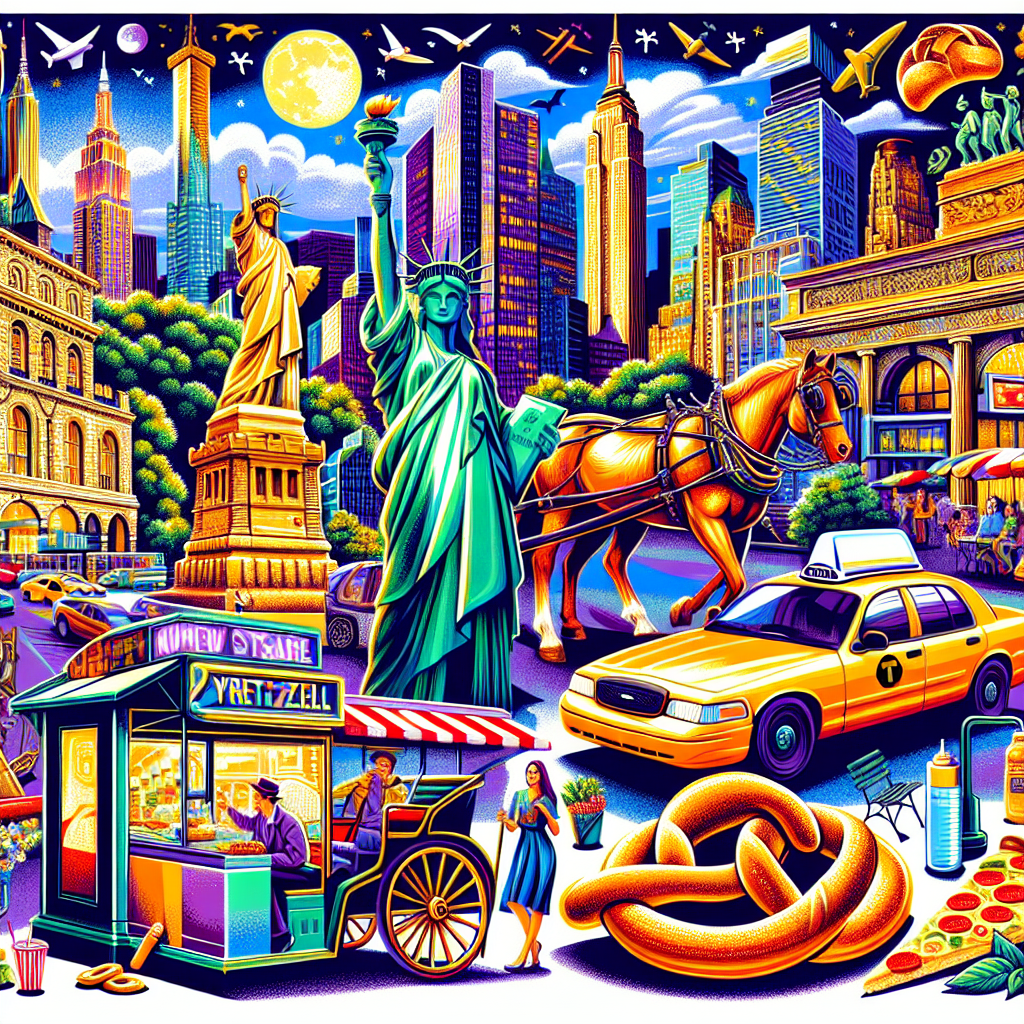

In [17]:
image = artist("New York City")
display(image)

In [27]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [29]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [30]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [31]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        print(f"message from chatbot:{message}")
        print(f"history from chatbot:{history}")
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


message from chatbot:hello
history from chatbot:[]
message from chatbot:hyderabad flight
history from chatbot:[{'role': 'user', 'metadata': None, 'content': 'hello', 'options': None}, {'role': 'assistant', 'metadata': None, 'content': 'Hello! How can I assist you with your flight today?', 'options': None}]
message from chatbot:yes
history from chatbot:[{'role': 'user', 'metadata': None, 'content': 'hello', 'options': None}, {'role': 'assistant', 'metadata': None, 'content': 'Hello! How can I assist you with your flight today?', 'options': None}, {'role': 'user', 'metadata': None, 'content': 'hyderabad flight', 'options': None}, {'role': 'assistant', 'metadata': None, 'content': 'Could you please specify if you want to book a ticket to Hyderabad or need information about flights from Hyderabad?', 'options': None}]
message from chatbot:yes, please
history from chatbot:[{'role': 'user', 'metadata': None, 'content': 'hello', 'options': None}, {'role': 'assistant', 'metadata': None, 'conten

# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>